# Chapter 36: Categorical Embeddings

**How large can the share of unseen categories get before an integer label code is worse than dropping the column, and what does the unknown rule cost a target encoding?**

Seen-category rows reward every encoding. The leaderboard may contain new products, users or zip codes, and then the unknown rule decides the score. The chapter asks for a documented dictionary and an explicit unknown code for this reason.

*Constructed data; frequency is strong here because unseen categories are rare by construction. The label code falls below the no-feature baseline because of where -1 lands in a popularity-ordered code; in random order it stays above it, and the crossover share moves with the random draw.*

## The experiment

A constructed binary task with 1,500 Zipf-popular training categories, 10,000 training rows, two numeric features and a category effect plus a rarity effect (rare categories have higher event rates). 6,000 test rows are drawn from the training categories, except for the control's share, which comes from 1,500 new categories. Five gradient-boosted models are compared by pooled AUC: no category feature, an integer label code numbered in order of first appearance, as pandas factorize numbers them (unknown = -1), frequency counts (unknown = 0), nested smoothed target means plus frequency with unknown = the training prior, and the same with unknown = 0. A sixth model numbers the same categories in random order, to show what the label code's result depends on. Results are means over 6 independent worlds.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

from kaggle_companion.activities._common import clean

SEED = 36
REPLICATES = 6                       # independent worlds per control value; results are means over them
SEEN, NEW = 1500, 1500               # categories that can appear in training, and a pool of new ones for test
N_TRAIN, N_TEST = 10_000, 6_000
M = 10.0                             # smoothing strength of the chapter's smoothed mean


def make_world(rng):
    """Zipf popularity for the training categories; a category effect plus a rarity effect (rare categories run hotter)."""
    p = 1 / np.arange(1, SEEN + 1) ** 0.9
    p /= p.sum()
    log_p = np.concatenate([np.log(p), np.full(NEW, np.log(p[-1]))])        # new categories are tail-rare
    rarity = -0.45 * (log_p - np.log(p).mean()) / np.log(p).std()
    return p, rng.normal(0, 0.7, SEEN + NEW) + rarity


def draw_rows(categories, effect, rng):
    x = rng.normal(size=(len(categories), 2))
    logit = -1.2 + 0.7 * x[:, 0] - 0.3 * x[:, 1] + effect[categories]
    return x, (rng.random(len(categories)) < 1 / (1 + np.exp(-logit))).astype(int)


def smoothed_means(cat, y, prior):
    """e_c = (s_c + m*mu) / (n_c + m). A category with n_c = 0 gets exactly the prior mu."""
    s = np.bincount(cat, weights=y, minlength=SEEN + NEW)
    n = np.bincount(cat, minlength=SEEN + NEW)
    return (s + M * prior) / (n + M)


def one_world(unseen_share, seed):
    rng = np.random.default_rng(seed)
    p, effect = make_world(rng)
    cat_tr = rng.choice(SEEN, N_TRAIN, p=p)
    x_tr, y_tr = draw_rows(cat_tr, effect, rng)
    n_new = int(round(unseen_share * N_TEST))
    cat_te = np.concatenate([rng.choice(SEEN, N_TEST - n_new, p=p), SEEN + rng.integers(0, NEW, n_new)])
    x_te, y_te = draw_rows(cat_te, effect, rng)

    known = np.zeros(SEEN + NEW, bool)
    known[cat_tr] = True
    unseen = ~known[cat_te]                                  # unseen means: absent from the training dictionary
    counts = np.bincount(cat_tr, minlength=SEEN + NEW)       # frequency encoding from training rows only; unseen -> 0
    codes = -np.ones(SEEN + NEW, int)                        # label codes in order of first appearance; unseen -> -1
    first = np.unique(cat_tr, return_index=True)
    order = first[0][np.argsort(first[1])]                   # in a shuffled table, first appearance follows popularity
    codes[order] = np.arange(known.sum())
    random_codes = -np.ones(SEEN + NEW, int)                 # the same categories numbered in random order; unseen -> -1
    random_codes[np.random.default_rng([seed, 1]).permutation(order)] = np.arange(known.sum())

    prior = y_tr.mean()
    te_train = np.zeros(N_TRAIN)                             # nested: each training row is encoded from the other folds
    for fit, out in KFold(5, shuffle=True, random_state=0).split(cat_tr):
        te_train[out] = smoothed_means(cat_tr[fit], y_tr[fit], y_tr[fit].mean())[cat_tr[out]]
    full_map = smoothed_means(cat_tr, y_tr, prior)
    te_known = np.where(known[cat_te], full_map[cat_te], prior)    # the documented rule: unknown -> training prior
    te_zero = np.where(known[cat_te], full_map[cat_te], 0.0)       # the shortcut: unknown -> 0

    arms = {                                                 # (training features, test features)
        "none": (x_tr, x_te),
        "label": (np.c_[x_tr, codes[cat_tr]], np.c_[x_te, codes[cat_te]]),
        "label_random": (np.c_[x_tr, random_codes[cat_tr]], np.c_[x_te, random_codes[cat_te]]),
        "frequency": (np.c_[x_tr, counts[cat_tr]], np.c_[x_te, counts[cat_te]]),
        "target_prior": (np.c_[x_tr, te_train, counts[cat_tr]], np.c_[x_te, te_known, counts[cat_te]]),
        "target_zero": (np.c_[x_tr, te_train, counts[cat_tr]], np.c_[x_te, te_zero, counts[cat_te]]),
    }
    scores = {}
    for name, (a, b) in arms.items():
        model = HistGradientBoostingClassifier(max_iter=80, max_leaf_nodes=15, random_state=0).fit(a, y_tr)
        pred = model.predict_proba(b)[:, 1]
        scores[name] = [roc_auc_score(y_te, pred), roc_auc_score(y_te[~unseen], pred[~unseen]),
                        roc_auc_score(y_te[unseen], pred[unseen])]
    return scores, float(unseen.mean())


def run(unseen_share):
    worlds = [one_world(unseen_share, SEED * 100 + r) for r in range(REPLICATES)]
    names = list(worlds[0][0])
    mean = {k: np.mean([w[0][k] for w in worlds], axis=0) for k in names}
    below = {k: float(np.mean([w[0][k][0] < w[0]["none"][0] for w in worlds])) for k in names}
    return clean({
        "unseen_share": unseen_share,
        "measured_unseen_share": float(np.mean([w[1] for w in worlds])),
        "auc": {k: mean[k][0] for k in names}, "auc_seen": {k: mean[k][1] for k in names},
        "auc_unseen": {k: mean[k][2] for k in names}, "below_no_feature": below,
        "replicates": REPLICATES, "test_rows": N_TEST,
    })


## Measure it across the control

The control is **share of test rows from categories absent in training**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch36 import explain

VALUES = [0, 0.1, 0.25, 0.5]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                  0    0.1   0.25    0.5
No categorical feature        0.650  0.660  0.646  0.646
Label code                    0.726  0.679  0.613  0.573
Frequency count               0.762  0.771  0.758  0.738
Target mean, unknown = prior  0.772  0.778  0.764  0.742
Target mean, unknown = 0      0.761  0.739  0.696  0.665
Unseen rows, label code       0.633  0.627  0.607  0.608
Label code, random order      0.721  0.729  0.718  0.698


## Look at it

The figure shows the default setting, share of test rows from categories absent in training = 0.25.

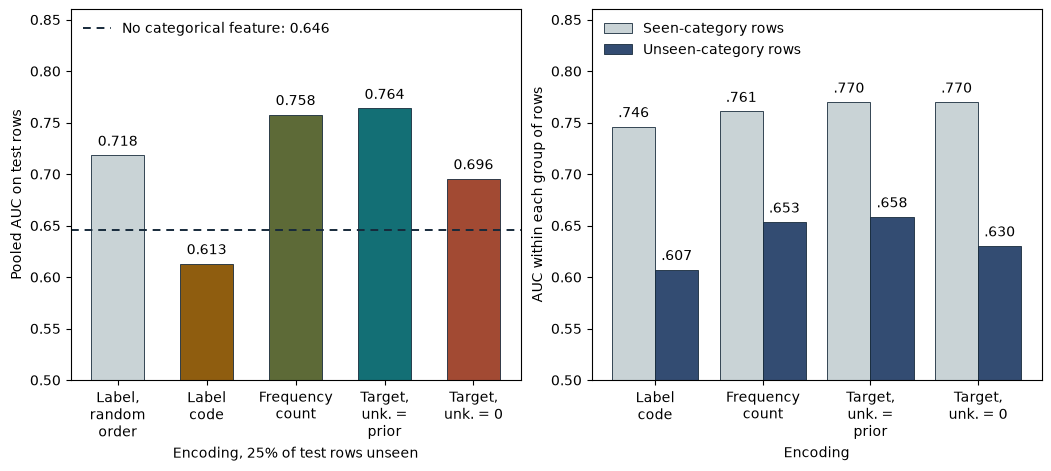

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch36 import draw, NCOLS, HEIGHT

DEFAULT = 0.25
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 25% of test rows from unseen categories (measured 27%), the label code scores 0.613 against 0.646 with no categorical feature, 0.613 - 0.646 = -0.033: worse than dropping the column. The target mean with the prior scores 0.764; with unknown = 0 it scores 0.696, so the unknown rule alone costs 0.764 - 0.696 = 0.068 AUC. Seen rows score 0.770 under both target rules. Best overall here: target mean with the prior, with frequency alone 0.006 behind the best target rule. Numbered in random order, the label code scores 0.718, so its result depends on where -1 lands.

- Label code against no feature: 0.613 - 0.646 = -0.033.
- Cost of unknown = 0: 0.764 - 0.696 = 0.068.
- Frequency against the best target rule: 0.764 - 0.758 = 0.006.
- Label code fell below the no-feature model in 83% of 6 worlds.

## Apply this to your competition

- Save the training dictionary, prior and counts with the model and map new categories through them; never recode at inference.
- Decide the unknown value for each encoding in writing: prior for target means, zero for frequency counts, a learned or neutral vector for embeddings.
- Build a validation slice with the unseen share you expect on the leaderboard (new users or items in a time split) and score encodings there.
- Keep frequency encoding as a cheap baseline: it needs no labels and handles new categories by construction.

Book location: Chapter 36, Handling Unseen Categories at Inference.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)